<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-burst-prediction/blob/main/MSc_project_data_pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# import packages required

from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Data Import

In [3]:
# upload into working space

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# import data

assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding='latin1')
bursts = pd.read_csv("/content/drive/MyDrive/MSc project/burst_data.csv", encoding='latin1')
soil = pd.read_csv("/content/drive/MyDrive/MSc project/soil-pipe-matched.csv", encoding ='latin1')

/tmp/ipykernel_19749/784720674.py:3: DtypeWarning: Columns (22,23,28) have mixed types. Specify dtype option on import or set low_memory=False.
  assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding='latin1')


# Data Cleaning

In [5]:
# assets cleaning

assets_cleaned = assets[assets["Type"] == "Distribution"] # only keeping distribution mains

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_DIAMETER"])] # deletes records with missing diameter

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_AGE"])] # deletes records with missing age

assets_cleaned = assets_cleaned[assets_cleaned["ARM_MATERIAL"] != "MISSING"] # removes assets with missing material

assets_cleaned = assets_cleaned[assets_cleaned["ARM_SURFACE_CODE"] != "MISSING"] # remove assets with missing surface code

assets_cleaned = assets_cleaned[assets_cleaned["ARM_SURFACE_CODE"] != "Unknown"] # remove assets with unknown surface code

assets_cleaned = assets_cleaned[assets_cleaned["Operational.Status"] != "Abandoned"] # remove abondened assets

assets_cleaned = assets_cleaned[assets_cleaned["Operational.Status"] != "Removed"] # remove removed assets

assets_cleaned = assets_cleaned[["Asset.ID",
                                 "ARM_MATERIAL",
                                 "ARM_DIAMETER",
                                 "ARM_LENGTH",
                                 "ARM_AGE",
                                 "ARM_LINING",
                                 "ARM_SURFACE_CODE"
                                 ]] # selecting attributes

assets_cleaned = assets_cleaned.rename(columns = {"ARM_MATERIAL":"Material",
                                                        "ARM_DIAMETER": "Diameter",
                                                        "ARM_LENGTH": "Length",
                                                        "ARM_AGE": "Age",
                                                        "ARM_LINING": "Lining",
                                                  "ARM_SURFACE_CODE": "Surface"}) # renaming columns

In [12]:
# bursts cleaning

bursts_cleaned = bursts[["Asset.ID", "Raised.Date"]]

bursts_cleaned["Raised.Date"] = pd.to_datetime(bursts_cleaned["Raised.Date"], dayfirst=True) # transofrms burst date to date format

/tmp/ipykernel_1536/17490745.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bursts_cleaned["Raised.Date"] = pd.to_datetime(bursts_cleaned["Raised.Date"], dayfirst=True) # transofrms burst date to date format


In [13]:
# soil cleaning

soil = soil[["Asset.ID", "Soil"]]

# Data manipulation

In [14]:
# merging assets, bursts and soil together

assets_bursts = pd.merge(assets_cleaned, bursts_cleaned, how = "left", on = "Asset.ID")

assets_bursts = assets_bursts[pd.notnull(assets_bursts["Raised.Date"])] # removing assets without bursts

assets_bursts_soil = pd.merge(assets_bursts, soil, how = "left", on = "Asset.ID")

assets_bursts_soil = assets_bursts_soil[pd.notnull(assets_bursts_soil["Soil"])] # removing assets without soil information

In [15]:
# identify assets with 2 or more bursts

counts = bursts["Asset.ID"].value_counts()
frequent_bursters = counts[counts >= 2].index



In [16]:
# filter merged data for assets with 2 or more bursts

assets_bursts_soil_frequent = assets_bursts_soil[assets_bursts_soil["Asset.ID"].isin(frequent_bursters)]

In [17]:
# calculate the no. of previous failures for assets with 2 or more bursts

previous_bursts = assets_bursts_soil_frequent['Asset.ID'].value_counts() - 1 # one substracted as that corresponds to future burst


In [18]:
# identify the latest two bursts for each asset

index = assets_bursts_soil_frequent.groupby("Asset.ID")["Raised.Date"].nlargest(2).reset_index(level = 0, drop = True).index

In [19]:
# subset data to contain only latest two bursts

assets_bursts_soil_frequent_subset = assets_bursts_soil_frequent.loc[index]

In [20]:
# sort using Asset ID and Date

assets_bursts_soil_frequent_subset = assets_bursts_soil_frequent_subset.sort_values(by = ["Asset.ID", "Raised.Date"])


In [21]:
# introduce a pivot column

burst = ["First", "Second"] * (int(assets_bursts_soil_frequent_subset.shape[0]/2))

assets_bursts_soil_frequent_subset["Burst"] = burst

In [22]:
# pivot date column

frequent_bursts_subset_tidy = assets_bursts_soil_frequent_subset.pivot(values = "Raised.Date", columns = "Burst", index = "Asset.ID").reset_index()


In [23]:
# merge pivoted column with the original assets and soil data

attributes = pd.merge(frequent_bursts_subset_tidy, assets_cleaned, how = "inner", on = "Asset.ID")

attributes = pd.merge(attributes, soil, on = "Asset.ID", how = "inner")


In [24]:
# merge with the no. of previous failures

attributes = pd.merge(attributes, previous_bursts, how = "inner", on = "Asset.ID")
attributes = attributes.rename(columns={"count":"previous fails"}) # change column name

In [25]:
# calculate and add time-to-break attribute

time_to_next_break = attributes["Second"] - attributes["First"]

attributes["Time-to-break"] = time_to_next_break

attributes["Time-to-break"] = attributes['Time-to-break'].astype("int64")/ (1e9 * 60 * 60 * 24) # convert to numeric data type (converted from nano seconds to days)

In [26]:
# save attributes

attributes.to_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding ='latin1', index=False)

# Feature engineering

In [6]:
attributes = pd.read_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding='latin1')

In [38]:
# removing Asset ID and dates - not needed for further analysis

attributes = attributes.iloc[:, 3:12]

In [55]:
attributes.dtypes

,0
Asset.ID,float64
First,object
Second,object
Material,object
Diameter,float64
Length,float64
Age,float64
Lining,object
Surface,object
Soil,object


### Numerical attributes

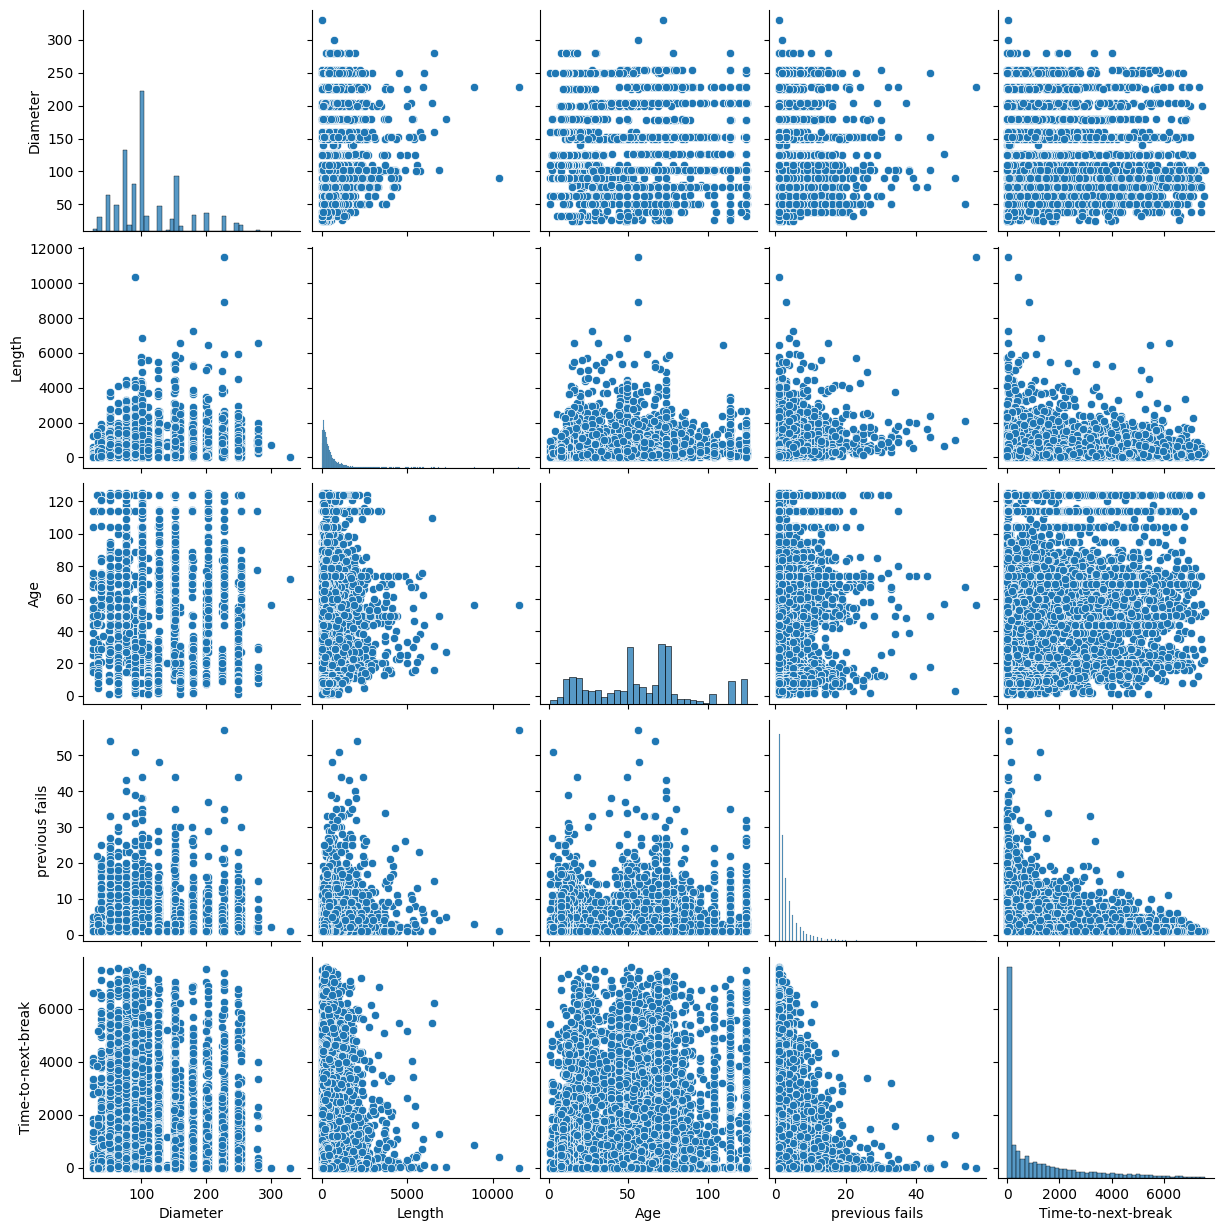

In [44]:
# examine correlations between numerical attributes

sns.pairplot(attributes)

Text(0, 0.5, 'Time-to-break (days)')

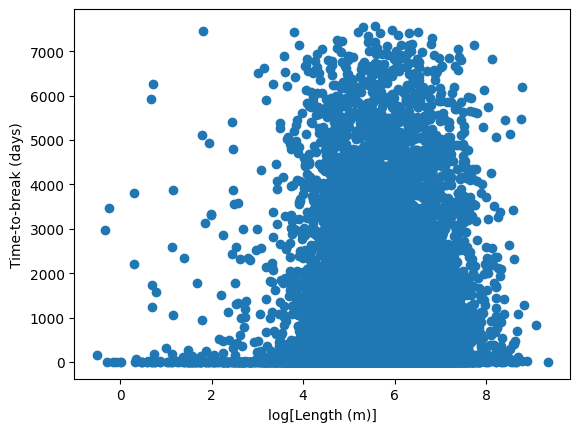

In [24]:
# length vs time-to-break

plt.scatter(np.log(attributes['Length']), attributes["Time-to-break"]) # take log of length as highly skewed
plt.xlabel("log[Length (m)]")
plt.ylabel("Time-to-break (days)")

# comment: no strong relationship

In [40]:
# length vs time-to-break

test = stats.spearmanr(a = attributes['Length'], b = attributes["Time-to-break"])

print(test.pvalue)
print(test.statistic)

# comment: weak positive relationship

1.6098925699828398e-22
0.09751024910570905


Text(0, 0.5, 'log[Time-to-break (days)]')

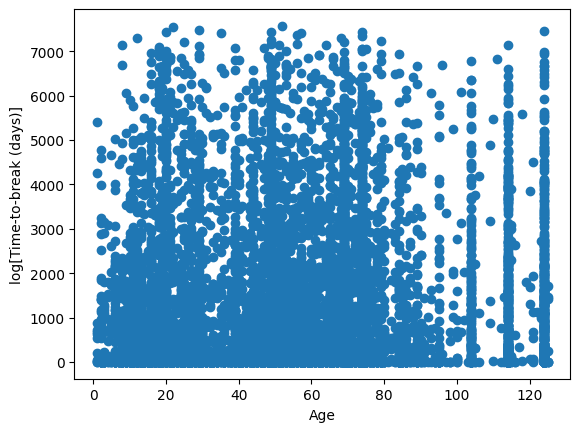

In [14]:
# time to break vs age

plt.scatter(attributes['Age'], attributes["Time-to-break"])
plt.xlabel("Age")
plt.ylabel("log[Time-to-break (days)]")

# comment: no relationship

In [41]:
# age vs time-to-break

test = stats.spearmanr(a = attributes['Age'], b = attributes["Time-to-break"])


print(test.pvalue)
print(test.statistic)

# comment: weak positive relationship

5.706749929472255e-11
0.06551231933770725


Text(0, 0.5, 'log[Time-to-break (days)]')

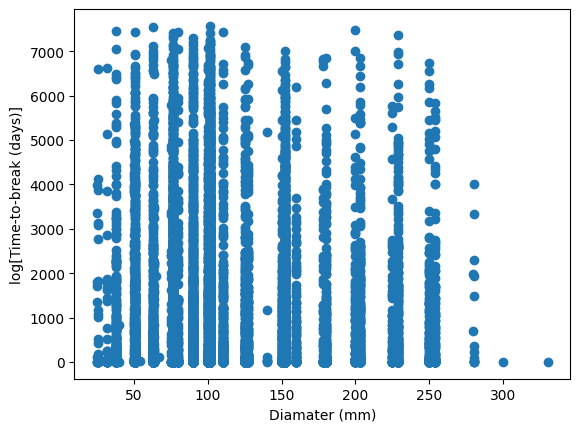

In [20]:
# diamater vs time to break

plt.scatter(attributes['Diameter'], attributes["Time-to-break"])
plt.xlabel("Diamater (mm)")
plt.ylabel("log[Time-to-break (days)]")

# comment: no obvious relationship

In [42]:
# diamater vs time-to-break

test = stats.spearmanr(a = attributes['Diameter'], b = attributes["Time-to-break"])

print(test.pvalue)
print(test.statistic)

# comment: weak negative relationship

0.005086468245257224
-0.028039711856694613


Text(0, 0.5, 'log[Time-to-break (days)]')

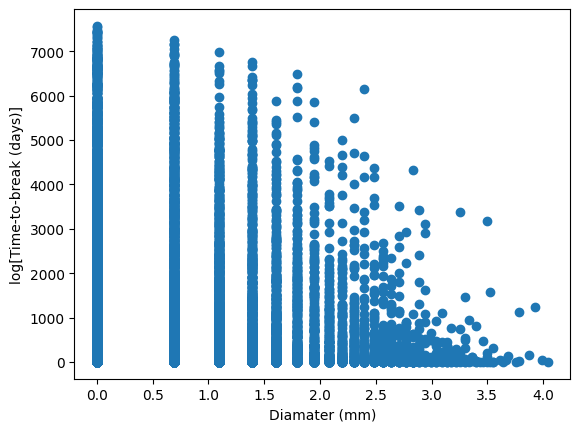

In [95]:
# previous fails vs time-to-break


plt.scatter(np.log(attributes['previous fails']), attributes["Time-to-break"]) # take logs of previous fails as highly skewed
plt.xlabel("Previous fails")
plt.ylabel("log[Time-to-break (days)]")

# comment: some negative relationship

In [43]:
# previous vs time-to-break

test = stats.spearmanr(a = attributes['previous fails'], b = attributes["Time-to-break"])

print(test.pvalue)
print(test.statistic)

# weak negative relationship

2.3599047136016995e-10
-0.06336328169445873


### Nominal attributes

<Axes: xlabel='Material', ylabel='Time-to-break'>

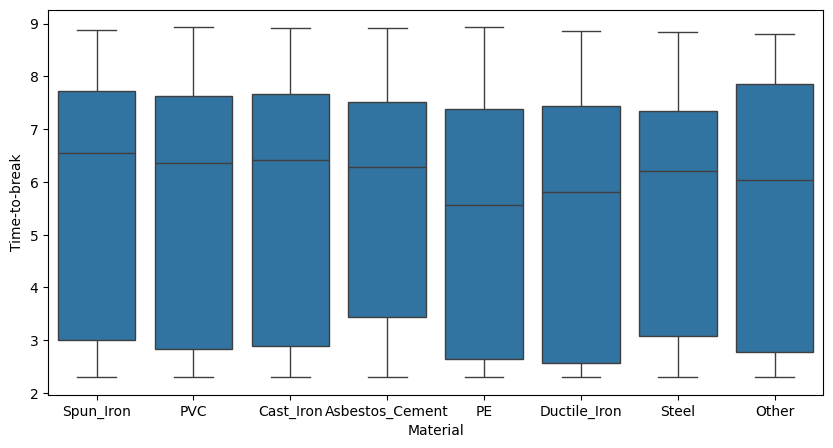

In [28]:
# material vs time-to-break

plt.figure(figsize = (10, 5))
sns.boxplot( y = np.log(attributes["Time-to-break"] + 10), x = attributes["Material"]) # adding a constant 10 to avoid infinity at time-to-break = 0

# comment: some materials such as PE or Steel seem to have slightly lower time-to-break

In [46]:
# splitting up material into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Material"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Material")


asbestos_cement = np.array(material_pivot["Asbestos_Cement"][pd.notnull(material_pivot["Asbestos_Cement"])])

spun_iron = np.array(material_pivot["Spun_Iron"][pd.notnull(material_pivot["Spun_Iron"])])

PVC = np.array(material_pivot["PVC"][pd.notnull(material_pivot["PVC"])])

cast_iron = np.array(material_pivot["Cast_Iron"][pd.notnull(material_pivot["Cast_Iron"])])

PE = np.array(material_pivot["PE"][pd.notnull(material_pivot["PE"])])

ductile_iron = np.array(material_pivot["Ductile_Iron"][pd.notnull(material_pivot["Ductile_Iron"])])

steel = np.array(material_pivot["Steel"][pd.notnull(material_pivot["Steel"])])

other = np.array(material_pivot["Other"][pd.notnull(material_pivot["Other"])])



In [47]:
# one-way ANOVA for material

test = stats.f_oneway(np.log(asbestos_cement + 10),
               np.log(spun_iron + 10),
               np.log(PVC + 10),
               np.log(cast_iron + 10),
               np.log(PE + 10),
               np.log(ductile_iron + 10),
               np.log(steel + 10),
               np.log(other + 10))

print(test.statistic)
print(test.pvalue)

# comment: significant different in time-to-break between different materials

9.705181697531483
4.257208478374827e-12


<Axes: xlabel='Soil', ylabel='Time-to-break'>

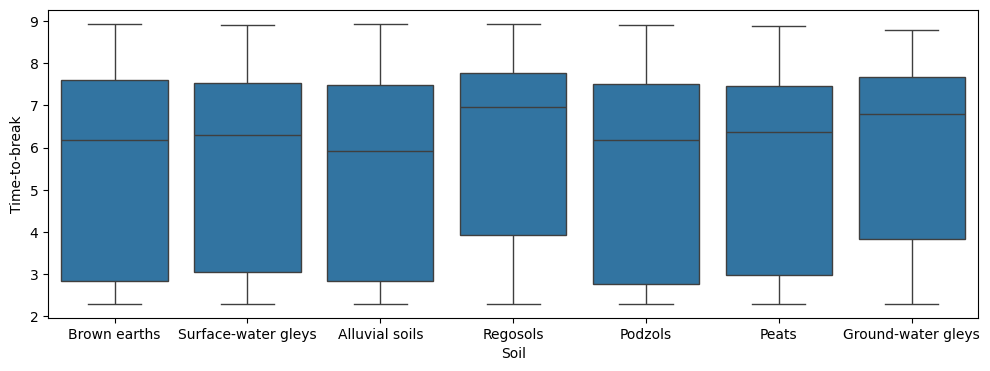

In [40]:
# soil vs time-to-break

plt.figure(figsize=(12,4))
sns.boxplot( y = np.log(attributes["Time-to-break"] + 10), x = attributes["Soil"])

# comment: some soil types appear to have longer time to break such as Regosols, and some have slightly shorter such as Peats

In [45]:
# splitting up soils into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Soil"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Soil")


brown_earths = np.array(material_pivot["Brown earths"][pd.notnull(material_pivot["Brown earths"])])

surface_water_gleys = np.array(material_pivot["Surface-water gleys"][pd.notnull(material_pivot["Surface-water gleys"])])

alluvial = np.array(material_pivot["Alluvial soils"][pd.notnull(material_pivot["Alluvial soils"])])

regosols = np.array(material_pivot["Regosols"][pd.notnull(material_pivot["Regosols"])])

podzols = np.array(material_pivot["Podzols"][pd.notnull(material_pivot["Podzols"])])

peats = np.array(material_pivot["Peats"][pd.notnull(material_pivot["Peats"])])

ground_water_gleys = np.array(material_pivot["Ground-water gleys"][pd.notnull(material_pivot["Ground-water gleys"])])



In [48]:
# one-way anova for soil

test = stats.f_oneway(np.log(brown_earths + 10),
               np.log(surface_water_gleys + 10),
               np.log(alluvial + 10),
               np.log(regosols + 10),
               np.log(podzols + 10),
               np.log(peats + 10),
               np.log(ground_water_gleys + 10))

print(test.statistic)
print(test.pvalue)

#comment: no significnat different between time-to-break by soil type

1.163800889044928
0.32253716598985677


<Axes: xlabel='Lining', ylabel='Time-to-break'>

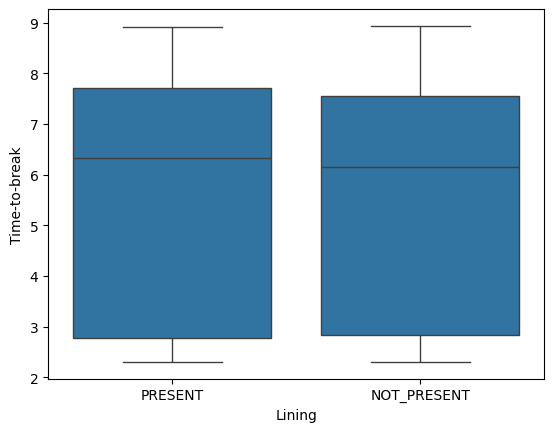

In [49]:
# lining vs time-to- break

sns.boxplot( y = np.log(attributes["Time-to-break"] + 10), x = attributes["Lining"])

# comment: assets with lining present appear to have longer time to break

In [50]:
# splitting up lining into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Lining"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Lining")


present = np.array(material_pivot["PRESENT"][pd.notnull(material_pivot["PRESENT"])])

not_present = np.array(material_pivot["NOT_PRESENT"][pd.notnull(material_pivot["NOT_PRESENT"])])


In [51]:
# one-way anova for lining

test = stats.f_oneway(np.log(present + 10),
               np.log(not_present + 10))

print(test.statistic)
print(test.pvalue)

#comment: no significnat different between time-to-break by lining

0.6731822493408697
0.41196392341067967


<Axes: xlabel='Surface', ylabel='Time-to-break'>

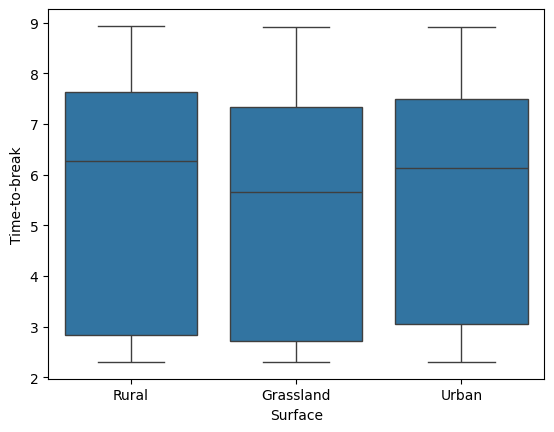

In [52]:
# time-to-break vs surface


sns.boxplot( y = np.log(attributes["Time-to-break"] + 10), x = attributes["Surface"])

In [53]:
# splitting up Surface into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Surface"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Surface")


rural = np.array(material_pivot["Rural"][pd.notnull(material_pivot["Rural"])])

grassland = np.array(material_pivot["Grassland"][pd.notnull(material_pivot["Grassland"])])

urban = np.array(material_pivot["Urban"][pd.notnull(material_pivot["Urban"])])

In [54]:
# one-way anova for surface

test = stats.f_oneway(np.log(rural + 10),
               np.log(grassland + 10),
                      np.log(urban + 10))

print(test.statistic)
print(test.pvalue)

#comment: significant difference between surface type detected

10.54541555337549
2.6608332600887963e-05
